In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np


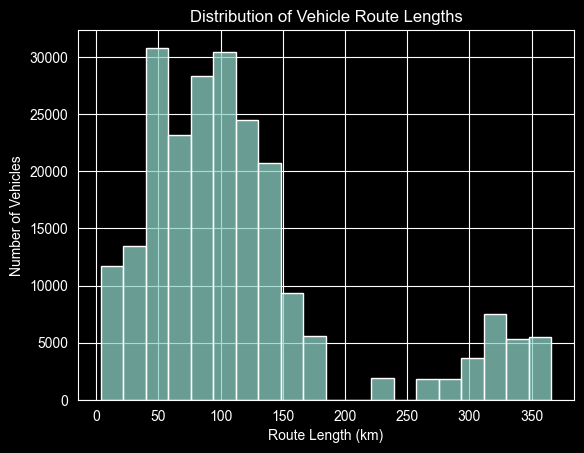

In [12]:
df_routes = pd.read_csv('scenario1_routes.csv')
sns.histplot(df_routes['route_length_km'], bins=20)
plt.xlabel("Route Length (km)")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Route Lengths")
plt.show()

Loaded 1108998 rows from 5 file(s)
scenario
0    225701
1    225581
2    223912
3    220840
4    212964
Name: count, dtype: int64


C:\Users\viola\AppData\Local\Temp\ipykernel_15796\1580394870.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


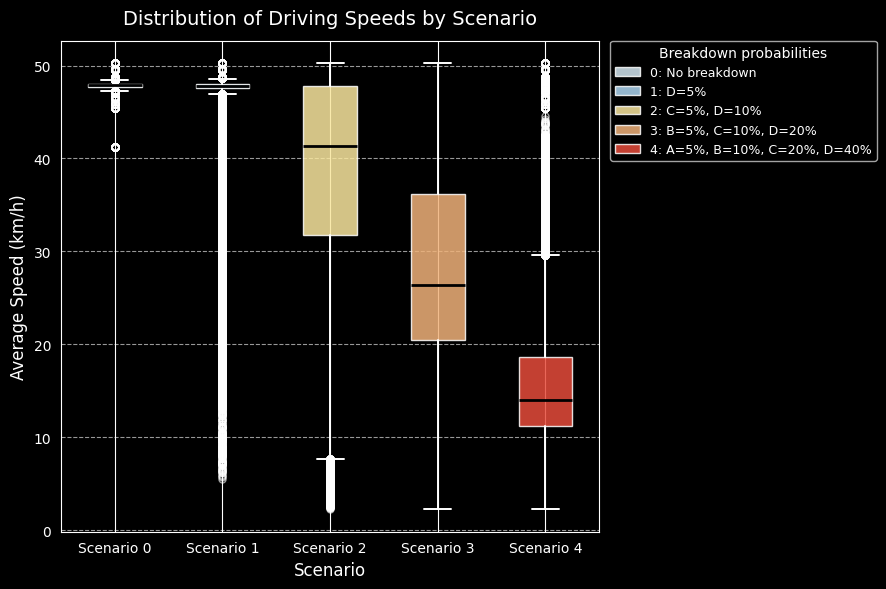

In [13]:
files = sorted(glob.glob("scenario*_routes.csv"))

if not files:
    raise FileNotFoundError("No scenario*_routes.csv files found in experiment/")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(data)} rows from {len(files)} file(s)")
print(data["scenario"].value_counts().sort_index())

# ── Compute speed (km/h) per trip: route_length_km / (driving_time_min / 60) ──
data["speed_kmh"] = data["route_length_km"] / (data["driving_time_min"] / 60)

# ── Build per-trip speed distribution per scenario ───────────────────────────
scenarios = sorted(data["scenario"].unique())
box_data  = [data[data["scenario"] == s]["speed_kmh"].values for s in scenarios]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(
    box_data,
    labels=[f"Scenario {s}" for s in scenarios],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.4),
    capprops=dict(linewidth=1.4),
    flierprops=dict(marker="o", markersize=5, linestyle="none", alpha=0.6),
)

# Colour boxes by scenario severity (light → dark red)
colors = ["#d4e6f1", "#aed6f1", "#f9e79f", "#f0b27a", "#e74c3c"]
for patch, color in zip(bp["boxes"], colors[:len(scenarios)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_title("Distribution of Driving Speeds by Scenario", fontsize=14, pad=12)
ax.set_xlabel("Scenario", fontsize=12)
ax.set_ylabel("Average Speed (km/h)", fontsize=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.6)
ax.set_axisbelow(True)

scenario_labels = [
    "0: No breakdown",
    "1: D=5%",
    "2: C=5%, D=10%",
    "3: B=5%, C=10%, D=20%",
    "4: A=5%, B=10%, C=20%, D=40%",
]
legend_handles = [
    plt.Rectangle((0,0), 1, 1, fc=colors[i], alpha=0.85)
    for i in range(len(scenarios))
]

ax.legend(
    legend_handles,
    scenario_labels[:len(scenarios)],
    title="Breakdown probabilities",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),  # <-- outside top-right
    fontsize=9,
    borderaxespad=0
)

plt.style.use('default')

plt.tight_layout()

plt.savefig("speed_boxplot.png")

plt.show()

In [14]:
# Compute mean speed per scenario
mean_speeds = data.groupby("scenario")["speed_kmh"].mean()

# Print nicely
for scenario, mean in mean_speeds.items():
    print(f"Scenario {scenario}: Mean speed = {mean:.2f} km/h")

Scenario 0: Mean speed = 47.80 km/h
Scenario 1: Mean speed = 46.77 km/h
Scenario 2: Mean speed = 38.93 km/h
Scenario 3: Mean speed = 28.77 km/h
Scenario 4: Mean speed = 16.72 km/h


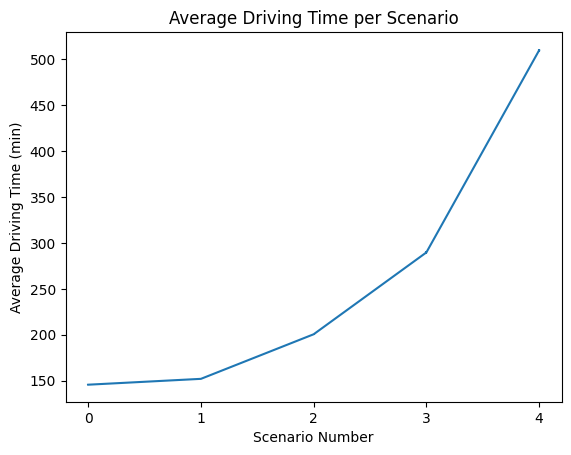

[145.5509063777266, 151.92106323796207, 200.49435036954824, 289.6727272049551, 509.8490964477786]


In [18]:
files = {}
for i in range(0, 5):
    files[i] = pd.read_csv(f'scenario{i}_A3.csv')

scenario_numbers = []
means = []
lower_errors = []
upper_errors = []

for key in files:
    df = files[key]

    number = df["scenario"].iloc[0]
    mean = df["scenario_mean"].iloc[0]
    ci_lower = df["ci_95_lower"].iloc[0]
    ci_upper = df["ci_95_upper"].iloc[0]

    scenario_numbers.append(number)
    means.append(mean)
    lower_errors.append(mean - ci_lower)
    upper_errors.append(ci_upper - mean)

plt.style.use('default')
plt.figure(facecolor='white')

plt.errorbar(
    scenario_numbers,
    means,
    yerr=[lower_errors, upper_errors],
)

plt.xticks([0, 1, 2, 3, 4])

plt.grid(False)  # remove grid lines

plt.xlabel("Scenario Number")
plt.ylabel("Average Driving Time (min)")
plt.title("Average Driving Time per Scenario")

plt.savefig("average_driving_time.png")

plt.show()

print(means)

In [19]:
# ── Load all scenario files ─────────────────────────────────────────────────────
files = sorted(glob.glob("scenario*_routes.csv"))

if not files:
    raise FileNotFoundError("No scenario*_routes.csv files found.")

dfs = [pd.read_csv(f) for f in files]
data = pd.concat(dfs, ignore_index=True)

# ── Compute speed (km/h) ───────────────────────────────────────────────────────
data["speed_kmh"] = data["route_length_km"] / (data["driving_time_min"] / 60)

# ── Weighted standard deviation function ──────────────────────────────────────
def weighted_std(values, weights):
    """Compute weighted standard deviation."""
    average = np.average(values, weights=weights)
    variance = np.average((values - average)**2, weights=weights)
    return np.sqrt(variance)

# ── Compute weighted variability per scenario ─────────────────────────────────
weighted_std_per_scenario = data.groupby("scenario").apply(
    lambda x: weighted_std(x["speed_kmh"], x["route_length_km"])
)

# ── Display results ───────────────────────────────────────────────────────────
print("Weighted Standard Deviation of Speed per Scenario (km/h):")
print(weighted_std_per_scenario)

Weighted Standard Deviation of Speed per Scenario (km/h):
scenario
0    0.267844
1    3.976858
2    8.769498
3    8.753801
4    5.809600
dtype: float64


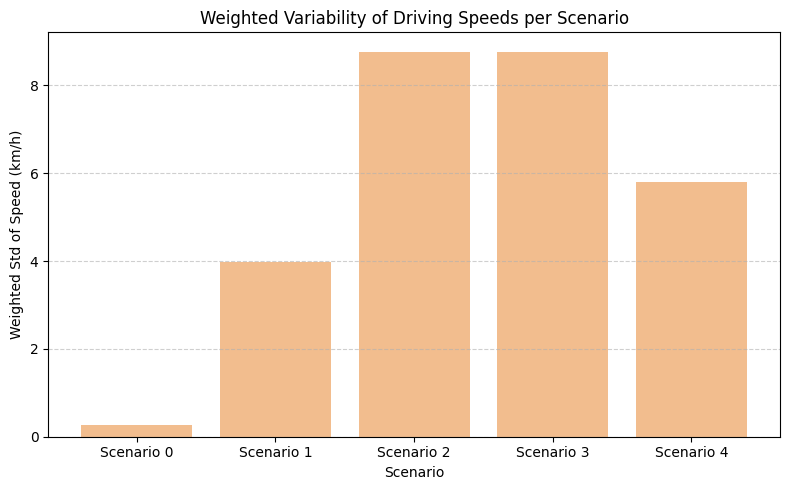

In [20]:
import matplotlib.pyplot as plt

# Ensure scenarios are sorted
scenarios = sorted(weighted_std_per_scenario.index)

plt.figure(figsize=(8,5))

# Bar plot of weighted standard deviation of speed
plt.bar(
    [f"Scenario {s}" for s in scenarios],
    weighted_std_per_scenario.values,
    color="#f0b27a",
    alpha=0.85
)

# Labels and title
plt.xlabel("Scenario")
plt.ylabel("Weighted Std of Speed (km/h)")
plt.title("Weighted Variability of Driving Speeds per Scenario")

# Optional: horizontal grid lines for readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("weighted_speed_variability.png", dpi=300, bbox_inches='tight')
plt.show()

Loaded 1108998 rows from 5 file(s)
scenario
0    225701
1    225581
2    223912
3    220840
4    212964
Name: count, dtype: int64


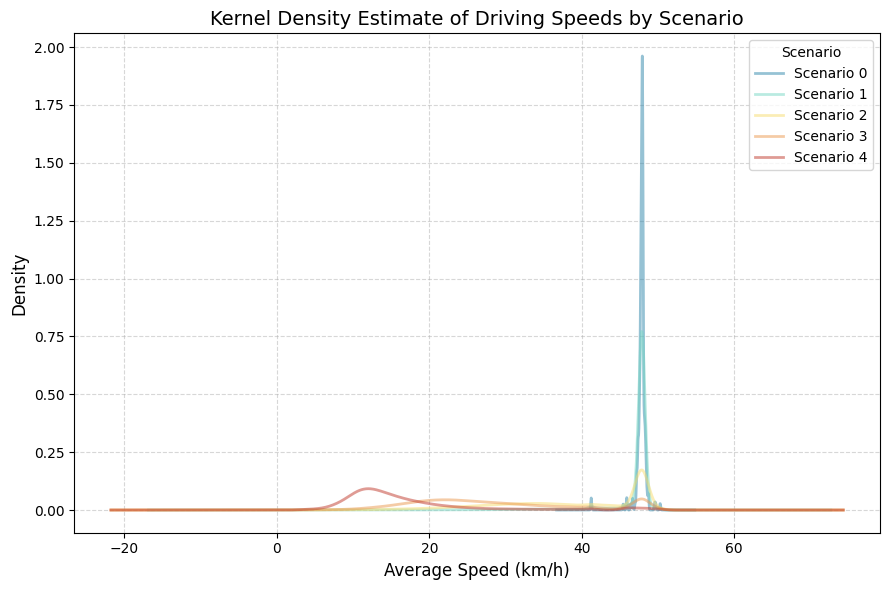

In [22]:
files = sorted(glob.glob("scenario*_routes.csv"))

if not files:
    raise FileNotFoundError("No scenario*_routes.csv files found in experiment/")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(data)} rows from {len(files)} file(s)")
print(data["scenario"].value_counts().sort_index())

# ── Compute speed (km/h) ─────────────────────────────────────────────
data["speed_kmh"] = data["route_length_km"] / (data["driving_time_min"] / 60)

# ── Plot KDE ─────────────────────────────────────────────────────────
plt.figure(figsize=(9, 6))

scenarios = sorted(data["scenario"].unique())
colors = ["#2E86AB", "#76D7C4", "#F7DC6F", "#EB984E", "#C0392B"]

for i, s in enumerate(scenarios):
    subset = data[data["scenario"] == s]["speed_kmh"]

    subset.plot(
        kind="kde",
        label=f"Scenario {s}",
        linewidth=2,
        color=colors[i % len(colors)],
        alpha = 0.5
    )

plt.title("Kernel Density Estimate of Driving Speeds by Scenario", fontsize=14)
plt.xlabel("Average Speed (km/h)", fontsize=12)
plt.ylabel("Density", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Scenario")

plt.tight_layout()
plt.savefig("speed_kde.png")
plt.show()